# NYC 311 Service Requests — Data Cleaning Pipeline

**Author:** Riley Allen | rileyallen2412@gmail.com  
**GitHub:** [github.com/ryry2412](https://github.com/ryry2412)  
**LinkedIn:** [linkedin.com/in/rileyallen2412](https://linkedin.com/in/rileyallen2412)  
**Dataset:** [NYC 311 Service Requests (2010–Present)](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9/about_data) — filtered Jan 2022 onward  
**Last updated:** 2025

---

## Project overview

This notebook demonstrates a **production-style data cleaning pipeline** applied to NYC's 311 Service Request dataset — one of the largest open civic datasets in the world, with millions of rows and a rich assortment of real-world data quality issues.

### Why this dataset?
NYC 311 data is an ideal cleaning challenge because it contains:
- **High missing value rates** across optional fields (e.g., cross streets, vehicle info)
- **Inconsistent text formatting** — borough names, agency codes, and complaint types entered by many different operators over many years
- **Date/time fields** stored as raw strings requiring parsing and validation
- **Logical inconsistencies** — closed dates before created dates, impossible response times
- **Duplicate records** from multi-agency routing
- **Rich opportunity for feature engineering** once the base data is clean

### Pipeline stages
| Stage | Description |
|-------|-------------|
| 1 | Load & inspect — understand raw data shape, types, nulls |
| 2 | Missing value analysis — visualize and make imputation decisions |
| 3 | Data type corrections — parse dates, cast numerics |
| 4 | Text normalization — standardize categoricals |
| 5 | Duplicate detection & removal |
| 6 | Feature engineering — response time, temporal features |
| 7 | Cleaning summary report — before/after comparison |

### Skills demonstrated
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `data wrangling` · `documentation`

---
## Setup — imports and configuration

In [1]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Stage 1 — Load & inspect

**Goal:** Load the raw CSV and get a comprehensive first look at the dataset's shape, column types, and null rates before touching anything.

**Why this matters:** Skipping the inspection phase leads to uninformed cleaning decisions. We document every observation here so that downstream choices are traceable and justifiable.

In [2]:
# Load raw data
# Source: NYC Open Data Socrata API — 200,000 rows, Jan 2022 onward
# API endpoint used to download:
#   https://data.cityofnewyork.us/resource/erm2-nwe9.csv
#     ?$limit=200000&$where=created_date>='2022-01-01'&$order=created_date DESC
#
# The CSV is saved locally as data/311_service_requests.csv and excluded
# from GitHub via .gitignore. See README for full reproduction instructions.
RAW_PATH = '../data/311_service_requests.csv'

df_raw = pd.read_csv(
    RAW_PATH,
    low_memory=False,   # prevents mixed-type warnings on large files
    dtype=str           # load everything as string first — we'll cast intentionally in Stage 3
)

print('Raw dataset loaded.')
print(f'  Source: NYC Open Data API (200k row sample, 2022–present)')
print(f'  Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Raw dataset loaded.
  Source: NYC Open Data API (200k row sample, 2022–present)
  Shape: 200,000 rows × 44 columns
  Memory usage: 543.2 MB


In [3]:
# Snapshot the initial shape for the final summary report (Stage 7)
# We track these metrics before any cleaning so we can show a before/after comparison
initial_shape = df_raw.shape
initial_nulls = df_raw.isnull().sum().sum()
initial_dupes = df_raw.duplicated().sum()

print('=== Baseline snapshot (pre-cleaning) ===')
print(f'  Rows:             {initial_shape[0]:>10,}')
print(f'  Columns:          {initial_shape[1]:>10,}')
print(f'  Total null cells: {initial_nulls:>10,}')
print(f'  Exact duplicates: {initial_dupes:>10,}')

=== Baseline snapshot (pre-cleaning) ===
  Rows:                200,000
  Columns:                  44
  Total null cells:  2,412,228
  Exact duplicates:          0


In [4]:
# First look at structure
# .info() gives us column names, non-null counts, and inferred dtypes
# Since we loaded everything as str, all dtypes show 'object' — that's expected
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   unique_key                      200000 non-null  object
 1   created_date                    200000 non-null  object
 2   closed_date                     161028 non-null  object
 3   agency                          200000 non-null  object
 4   agency_name                     200000 non-null  object
 5   complaint_type                  200000 non-null  object
 6   descriptor                      196298 non-null  object
 7   descriptor_2                    72091 non-null   object
 8   location_type                   170697 non-null  object
 9   incident_zip                    198126 non-null  object
 10  incident_address                191883 non-null  object
 11  street_name                     191883 non-null  object
 12  cross_street_1                

In [5]:
# Sample rows — visual sanity check
# Transposing makes wide datasets much easier to read
df_raw.head(3).T

,0,1,2
unique_key,68864898,68866173,68861668
created_date,2026-05-03T02:09:59.000,2026-05-03T02:07:33.000,2026-05-03T01:51:51.000
closed_date,2026-05-03T02:09:59.000,2026-05-03T02:07:33.000,NaN
agency,DOT,DOT,DOT
agency_name,Department of Transportation,Department of Transportation,Department of Transportation
complaint_type,Street Condition,Street Condition,Street Condition
descriptor,Pothole,Pothole,Pothole
descriptor_2,NaN,NaN,NaN
location_type,NaN,NaN,NaN
incident_zip,10314,10314,11368


In [6]:
# Null rate per column — sorted descending
# This tells us which columns are mostly empty and may need to be dropped
null_rates = (
    df_raw.isnull().sum()
    .div(len(df_raw))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename('null_pct')
    .reset_index()
    .rename(columns={'index': 'column'})
)

print('Top 20 columns by null rate:')
print(null_rates.head(20).to_string(index=False))

Top 20 columns by null rate:
                        column  null_pct
          taxi_company_borough     99.92
                     road_ramp     99.73
      bridge_highway_direction     99.72
                 facility_type     99.69
                      due_date     99.62
        bridge_highway_segment     99.48
           bridge_highway_name     99.48
         taxi_pick_up_location     98.88
                  vehicle_type     94.66
                  descriptor_2     63.95
                      landmark     39.17
         intersection_street_2     31.00
         intersection_street_1     30.99
                cross_street_2     26.54
                cross_street_1     26.50
                   closed_date     19.49
                 location_type     14.65
                           bbl     13.26
        resolution_description      7.59
resolution_action_updated_date      6.48


In [7]:
# Drop columns with >80% null values — these carry too little signal to be useful
# Decision rationale: a column missing in 80%+ of rows cannot be reliably imputed
# and would add noise rather than value to any downstream analysis
HIGH_NULL_THRESHOLD = 80.0

cols_to_drop = null_rates.loc[
    null_rates['null_pct'] >= HIGH_NULL_THRESHOLD, 'column'
].tolist()

print(f'Columns with ≥{HIGH_NULL_THRESHOLD}% nulls (will be dropped):')
for col in cols_to_drop:
    pct = null_rates.loc[null_rates['column'] == col, 'null_pct'].values[0]
    print(f'  {col:<45} {pct:.1f}% null')

df = df_raw.drop(columns=cols_to_drop).copy()
print(f'\nColumns remaining after drop: {df.shape[1]}')

Columns with ≥80.0% nulls (will be dropped):
  taxi_company_borough                          99.9% null
  road_ramp                                     99.7% null
  bridge_highway_direction                      99.7% null
  facility_type                                 99.7% null
  due_date                                      99.6% null
  bridge_highway_segment                        99.5% null
  bridge_highway_name                           99.5% null
  taxi_pick_up_location                         98.9% null
  vehicle_type                                  94.7% null

Columns remaining after drop: 35


---
## Stage 2 — Missing value analysis

**Goal:** Visualize the null pattern across remaining columns and make deliberate, documented decisions about how to handle each group of missing values.

**Decision framework used:**
- **Drop the column** — >80% null (handled in Stage 1) or structurally irrelevant
- **Drop the row** — null in a critical identifier column (e.g., `Unique Key`, `Created Date`)
- **Fill with sentinel** — null is meaningful (e.g., 'UNKNOWN' for optional location fields)
- **Leave as-is** — null is genuinely not applicable (e.g., vehicle info for non-vehicle complaints)

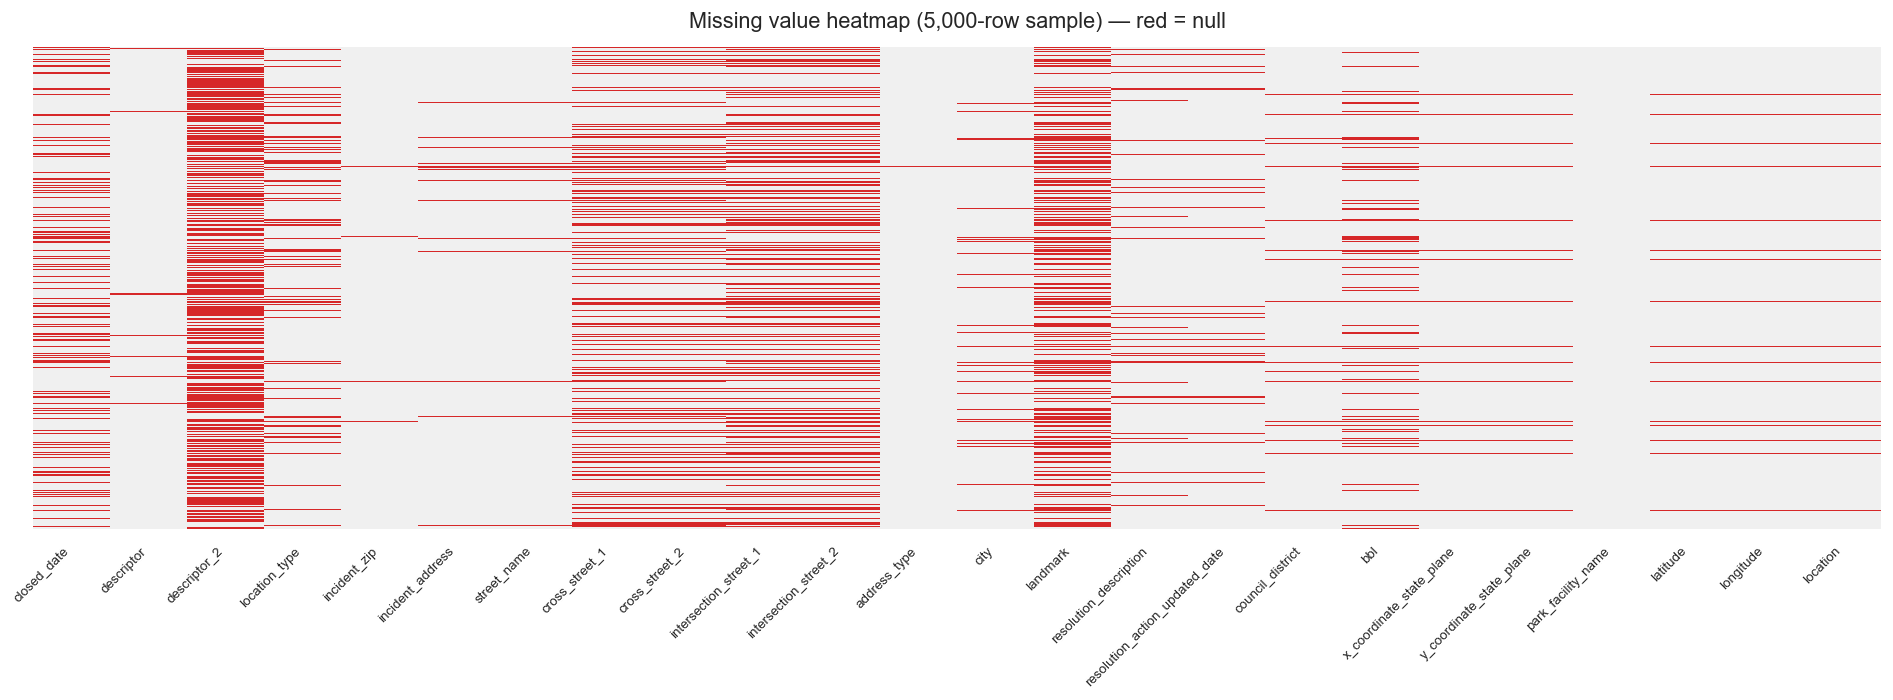

Figure saved to data/fig_null_heatmap.png


In [8]:
# Null heatmap — visually shows which columns have missing data and where
# Using a sample for performance on large datasets
SAMPLE_N = min(5000, len(df))
sample = df.sample(SAMPLE_N, random_state=42)

# Identify columns that still have any nulls
cols_with_nulls = df.columns[df.isnull().any()].tolist()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    sample[cols_with_nulls].isnull(),
    cbar=False,
    cmap=['#f0f0f0', '#d62728'],   # gray = present, red = missing
    yticklabels=False,
    ax=ax
)
ax.set_title('Missing value heatmap (5,000-row sample) — red = null', fontsize=13, pad=12)
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../data/fig_null_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved to data/fig_null_heatmap.png')

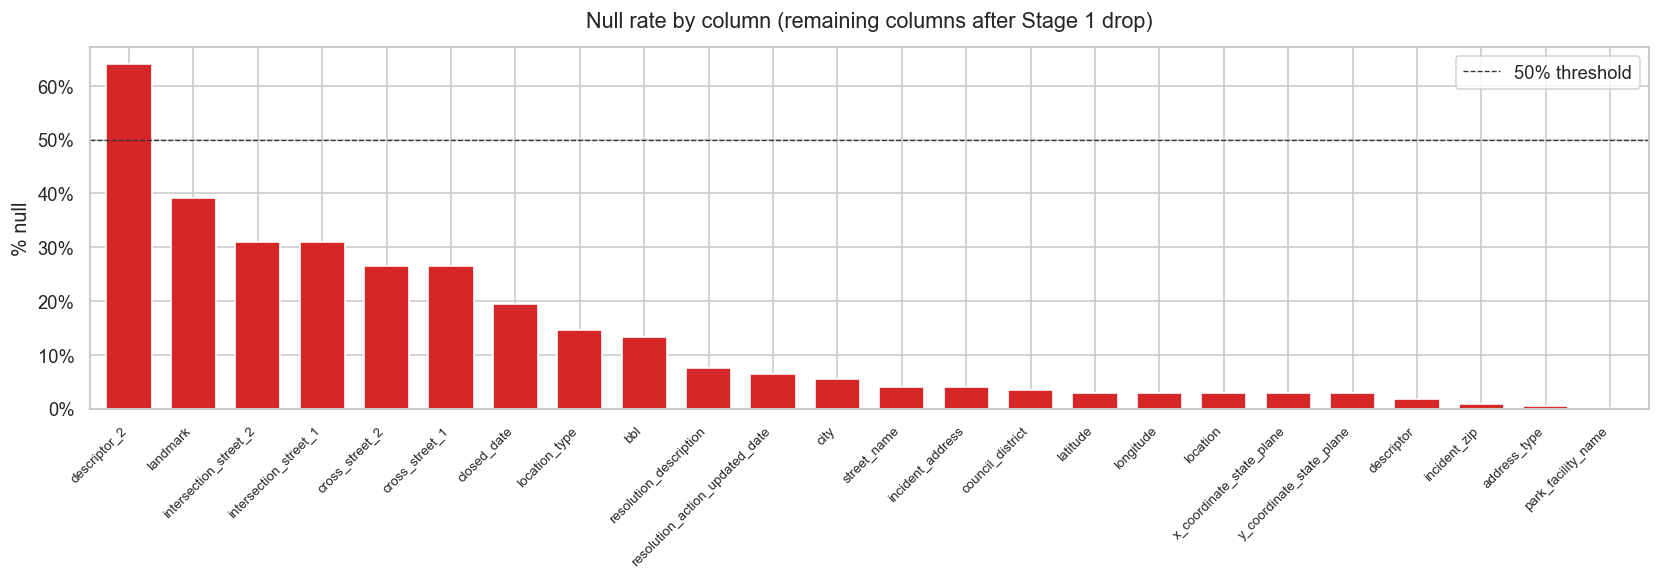

In [9]:
# Bar chart of null rates for columns that still have any missing values
remaining_nulls = (
    df[cols_with_nulls].isnull().mean().mul(100).sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
remaining_nulls.plot(kind='bar', ax=ax, color='#d62728', edgecolor='white', width=0.7)
ax.axhline(y=50, color='#333', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_title('Null rate by column (remaining columns after Stage 1 drop)', fontsize=13, pad=12)
ax.set_ylabel('% null')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig('../data/fig_null_rates.png', bbox_inches='tight')
plt.show()

In [10]:
# --- Handling decision 1: Drop rows with null critical identifiers ---
# 'unique_key' and 'created_date' are essential; a row without them
# cannot be meaningfully identified or placed in time.
critical_cols = ['unique_key', 'created_date']

rows_before = len(df)
df = df.dropna(subset=critical_cols)
rows_after = len(df)

print(f'Rows dropped (null critical identifier): {rows_before - rows_after:,}')
print(f'Rows remaining: {rows_after:,}')

Rows dropped (null critical identifier): 0
Rows remaining: 200,000


In [11]:
# --- Handling decision 2: Fill optional location fields with 'UNKNOWN' ---
# Fields like 'cross_street_1', 'cross_street_2', 'landmark' are optional at intake.
# Null here means 'not provided', not 'data error'. We sentinel-fill to preserve rows.
location_optional = [
    'cross_street_1', 'cross_street_2', 'intersection_street_1',
    'intersection_street_2', 'landmark', 'address_type'
]

# Only fill columns that actually exist in the dataset after Stage 1 drops
location_optional = [c for c in location_optional if c in df.columns]

df[location_optional] = df[location_optional].fillna('UNKNOWN')
print(f'Sentinel-filled {len(location_optional)} optional location columns with "UNKNOWN".')

Sentinel-filled 6 optional location columns with "UNKNOWN".


In [13]:
# --- Handling decision 3: Fill 'closed_date' nulls with NaT (after parsing in Stage 3) ---
# Closed Date is null for open/unresolved requests — this is semantically valid.
# We will keep these nulls intentionally; they'll become NaT after datetime parsing.
# This is documented here so the decision is traceable.
print('Closed Date nulls: intentionally preserved (open requests have no close date).')
print(f'  Null count: {df["closed_date"].isnull().sum():,} rows')

Closed Date nulls: intentionally preserved (open requests have no close date).
  Null count: 38,972 rows


---
## Stage 3 — Data type corrections

**Goal:** Cast all columns to their correct data types. Since we loaded everything as `str` in Stage 1, we now make intentional casting decisions with proper error handling.

**Why load as string first?** Loading as string prevents Pandas from making silent, incorrect type assumptions on messy columns. We control every cast explicitly.

In [14]:
# --- Date columns ---
# 'coerce' converts unparseable values to NaT instead of raising an error.
# This is safer than errors='raise' on civic data, which often has format inconsistencies.
date_columns = ['created_date', 'closed_date', 'due_date', 'resolution_action_updated_date']
date_columns = [c for c in date_columns if c in df.columns]

for col in date_columns:
    original_nulls = df[col].isnull().sum()
    df[col] = pd.to_datetime(df[col], errors='coerce')
    new_nulls = df[col].isnull().sum()
    coerced = new_nulls - original_nulls
    print(f'  {col:<45} parsed | {coerced:,} values coerced to NaT')

print('\nDate parsing complete.')

  created_date                                  parsed | 0 values coerced to NaT
  closed_date                                   parsed | 0 values coerced to NaT
  resolution_action_updated_date                parsed | 0 values coerced to NaT

Date parsing complete.


In [15]:
# --- Numeric columns ---
# Latitude and Longitude should be float. 'X Coordinate' and 'Y Coordinate' are NYC state plane coords.
numeric_columns = ['latitude', 'longitude', 'x_coordinate_state_plane', 'y_coordinate_state_plane']
numeric_columns = [c for c in numeric_columns if c in df.columns]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'  {col:<45} → float64 | nulls: {df[col].isnull().sum():,}')

print('\nNumeric casting complete.')

  latitude                                      → float64 | nulls: 5,921
  longitude                                     → float64 | nulls: 5,921
  x_coordinate_state_plane                      → float64 | nulls: 5,914
  y_coordinate_state_plane                      → float64 | nulls: 5,897

Numeric casting complete.


In [16]:
# --- Validate coordinate ranges ---
# NYC bounding box (approximate):
#   Latitude:  40.48 to 40.92
#   Longitude: -74.28 to -73.68
# Rows outside this range are likely data entry errors and should be nullified

if 'latitude' in df.columns and 'longitude' in df.columns:
    invalid_coords = (
        (df['latitude'] < 40.48) | (df['latitude'] > 40.92) |
        (df['longitude'] < -74.28) | (df['longitude'] > -73.68)
    ) & df['latitude'].notna()

    df.loc[invalid_coords, ['latitude', 'longitude']] = np.nan
    print(f'Invalid coordinate pairs nullified: {invalid_coords.sum():,}')

Invalid coordinate pairs nullified: 0


In [17]:
# --- Logical date validation ---
# 'closed_date' should never be before 'created_date'.
# These are data entry errors — we null the Closed Date in such cases.

if 'closed_date' in df.columns:
    invalid_dates = df['closed_date'] < df['created_date']
    df.loc[invalid_dates, 'closed_date'] = pd.NaT
    print(f'Closed Date before Created Date (nullified): {invalid_dates.sum():,}')

Closed Date before Created Date (nullified): 23


---
## Stage 4 — Text normalization

**Goal:** Standardize all categorical text fields so that the same conceptual value is represented identically throughout the dataset.

**Why it matters:** 'BROOKLYN', 'Brooklyn', 'brooklyn', and 'Bklyn' all refer to the same borough, but Pandas treats them as 4 distinct values. This breaks groupbys, value counts, and any downstream analysis or dashboard.

In [18]:
# Helper: show distinct values for a column before normalization
def inspect_categoricals(df, col, top_n=20):
    """Print value counts for a column to reveal inconsistencies."""
    print(f'--- {col} ({df[col].nunique()} unique values) ---')
    print(df[col].value_counts(dropna=False).head(top_n).to_string())
    print()

In [19]:
# Inspect Borough before cleaning
if 'borough' in df.columns:
    inspect_categoricals(df, 'borough')

--- borough (6 unique values) ---
borough
BROOKLYN         62834
QUEENS           48800
MANHATTAN        41062
BRONX            39275
STATEN ISLAND     7777
Unspecified        252



In [20]:
# --- Step 1: Strip whitespace and standardize case across all object columns ---
# We apply this universally before any specific remapping
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    df[col] = df[col].str.strip().str.upper()

print(f'Stripped whitespace and uppercased {len(object_cols)} text columns.')

Stripped whitespace and uppercased 28 text columns.


In [21]:
# --- Step 2: Borough normalization ---
# Common variants found in the dataset, mapped to clean canonical values
borough_map = {
    'BROOKLYN':          'BROOKLYN',
    'BRONX':             'BRONX',
    'THE BRONX':         'BRONX',
    'MANHATTAN':         'MANHATTAN',
    'NEW YORK':          'MANHATTAN',   # 'New York' used for Manhattan in some records
    'QUEENS':            'QUEENS',
    'STATEN ISLAND':     'STATEN ISLAND',
    'UNSPECIFIED':       'UNKNOWN',
    'N/A':               'UNKNOWN',
}

if 'borough' in df.columns:
    df['borough'] = df['borough'].replace(borough_map)
    # Any value not in the map stays as-is; we'll catch residual unknowns below
    df['borough'] = df['borough'].fillna('UNKNOWN')
    print('After normalization:')
    inspect_categoricals(df, 'borough')

After normalization:
--- borough (6 unique values) ---
borough
BROOKLYN         62834
QUEENS           48800
MANHATTAN        41062
BRONX            39275
STATEN ISLAND     7777
UNKNOWN            252



In [22]:
# --- Step 3: Status normalization ---
# Consolidate open/closed/pending variants
status_map = {
    'OPEN':              'OPEN',
    'ASSIGNED':          'OPEN',
    'IN PROGRESS':       'OPEN',
    'PENDING':           'OPEN',
    'CLOSED':            'CLOSED',
    'EMAIL SENT':        'CLOSED',
    'CANCELLED':         'CLOSED',
}

if 'status' in df.columns:
    df['status'] = df['status'].replace(status_map).fillna('UNKNOWN')
    print('Status after normalization:')
    print(df['status'].value_counts().to_string())

Status after normalization:
status
CLOSED         157739
OPEN            41573
STARTED           679
UNSPECIFIED         9


In [24]:
# --- Step 4: Complaint Type — trim to top N + 'OTHER' ---
# There are hundreds of complaint type variants. For analysis we keep the top 30
# and bucket the rest as 'OTHER'. This makes groupby analysis tractable.

if 'complaint_type' in df.columns:
    TOP_N = 30
    top_complaints = df['complaint_type'].value_counts().nlargest(TOP_N).index
    df['complaint_type'] = df['complaint_type'].where(
        df['complaint_type'].isin(top_complaints), other='OTHER'
    )
    print(f'Complaint Type: kept top {TOP_N}, bucketed rest as "OTHER".')
    print(f'Unique values now: {df["complaint_type"].nunique()}')

Complaint Type: kept top 30, bucketed rest as "OTHER".
Unique values now: 30


---
## Stage 5 — Duplicate detection & removal

**Goal:** Identify and remove duplicate records. In 311 data, duplicates can arise from:
1. **Exact duplicates** — the same row ingested twice (system error)
2. **Near-duplicates** — same complaint, same address, same day, different `Unique Key` (multi-agency routing)

We handle both, with documented rationale for each decision.

In [25]:
# --- Exact duplicates (all columns identical) ---
exact_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {exact_dupes:,}')

df = df.drop_duplicates()
print(f'Rows after exact deduplication: {len(df):,}')

Exact duplicate rows: 0
Rows after exact deduplication: 200,000


In [26]:
# --- Near-duplicates by Unique Key ---
# 'unique_key' should be the primary identifier. If it appears more than once,
# those are system-level duplicates we should keep only the first occurrence of.

if 'unique_key' in df.columns:
    key_dupes = df.duplicated(subset=['unique_key']).sum()
    print(f'Rows with duplicate Unique Key: {key_dupes:,}')

    df = df.drop_duplicates(subset=['unique_key'], keep='first')
    print(f'Rows after Unique Key deduplication: {len(df):,}')

Rows with duplicate Unique Key: 0
Rows after Unique Key deduplication: 200,000


In [27]:
# --- Business-logic near-duplicates ---
# Definition: same complaint type, same address, same borough, same date
# These represent the same underlying citizen complaint routed to multiple agencies.
# We keep the first occurrence (earliest agency assignment) and drop the rest.

near_dupe_cols = ['complaint_type', 'incident_address', 'borough', 'created_date']
near_dupe_cols = [c for c in near_dupe_cols if c in df.columns]

# For date-level matching, extract date only (not time)
if 'created_date' in df.columns:
    df['_created_date_only'] = df['created_date'].dt.date
    near_dupe_cols_adj = [
        c if c != 'created_date' else '_created_date_only'
        for c in near_dupe_cols
    ]
else:
    near_dupe_cols_adj = near_dupe_cols

near_dupe_cols_adj = [c for c in near_dupe_cols_adj if c in df.columns]
before = len(df)
df = df.drop_duplicates(subset=near_dupe_cols_adj, keep='first')

# Drop the helper column
if '_created_date_only' in df.columns:
    df = df.drop(columns=['_created_date_only'])

print(f'Business-logic near-duplicates removed: {before - len(df):,}')
print(f'Rows remaining: {len(df):,}')

Business-logic near-duplicates removed: 44,207
Rows remaining: 155,793


---
## Stage 6 — Feature engineering

**Goal:** Extract analytically useful features from the cleaned data. This transforms a cleaning exercise into something actionable — these new columns are what an analyst or BI tool would actually use.

**Features we'll create:**
| New column | Source | Description |
|------------|--------|-------------|
| `response_hours` | Closed Date − Created Date | Time to close a request, in hours |
| `day_of_week` | Created Date | Day name (Monday–Sunday) |
| `hour_of_day` | Created Date | Hour 0–23 |
| `month` | Created Date | Month 1–12 |
| `season` | Created Date | Winter / Spring / Summer / Fall |
| `is_weekend` | Created Date | Boolean — Sat/Sun = True |

In [28]:
# --- Response time in hours ---
if 'closed_date' in df.columns and 'created_date' in df.columns:
    df['response_hours'] = (
        (df['closed_date'] - df['created_date'])
        .dt.total_seconds()
        .div(3600)
        .round(2)
    )

    # Cap at 8760 hours (1 year) — anything beyond is likely a data error
    cap = 8760
    capped = (df['response_hours'] > cap).sum()
    df.loc[df['response_hours'] > cap, 'response_hours'] = np.nan
    print(f'response_hours created. Values capped (>{cap}h): {capped:,}')
    print(df['response_hours'].describe())

response_hours created. Values capped (>8760h): 0
count   125101.00
mean        25.98
std         55.22
min          0.00
25%          1.00
50%          3.36
75%         21.87
max        459.65
Name: response_hours, dtype: float64


In [29]:
# --- Temporal features from Created Date ---
if 'created_date' in df.columns:
    df['day_of_week'] = df['created_date'].dt.day_name()
    df['hour_of_day'] = df['created_date'].dt.hour
    df['month']       = df['created_date'].dt.month
    df['is_weekend']  = df['created_date'].dt.dayofweek >= 5  # 5=Sat, 6=Sun

    # Season mapping
    def month_to_season(m):
        if m in [12, 1, 2]:  return 'WINTER'
        if m in [3, 4, 5]:   return 'SPRING'
        if m in [6, 7, 8]:   return 'SUMMER'
        return 'FALL'

    df['season'] = df['month'].map(month_to_season)

    print('Temporal features created: day_of_week, hour_of_day, month, is_weekend, season')
    print(df[['day_of_week', 'hour_of_day', 'month', 'is_weekend', 'season']].head(3))

Temporal features created: day_of_week, hour_of_day, month, is_weekend, season
  day_of_week  hour_of_day  month  is_weekend  season
0      Sunday            2      5        True  SPRING
1      Sunday            2      5        True  SPRING
2      Sunday            1      5        True  SPRING


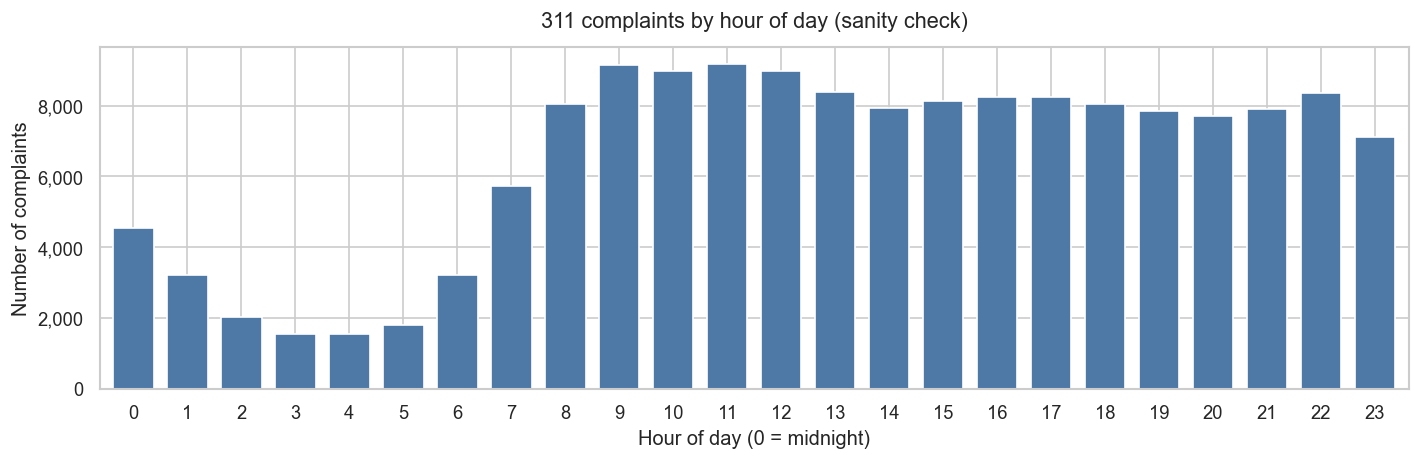

In [30]:
# --- Quick validation chart: complaints by hour of day ---
# This serves as a sanity check — we'd expect a peak during business hours
# and a dip overnight. Unexpected patterns would flag data quality issues.

if 'hour_of_day' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 4))
    df['hour_of_day'].value_counts().sort_index().plot(
        kind='bar', ax=ax, color='#4e79a7', edgecolor='white', width=0.75
    )
    ax.set_title('311 complaints by hour of day (sanity check)', fontsize=13, pad=12)
    ax.set_xlabel('Hour of day (0 = midnight)')
    ax.set_ylabel('Number of complaints')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../data/fig_complaints_by_hour.png', bbox_inches='tight')
    plt.show()

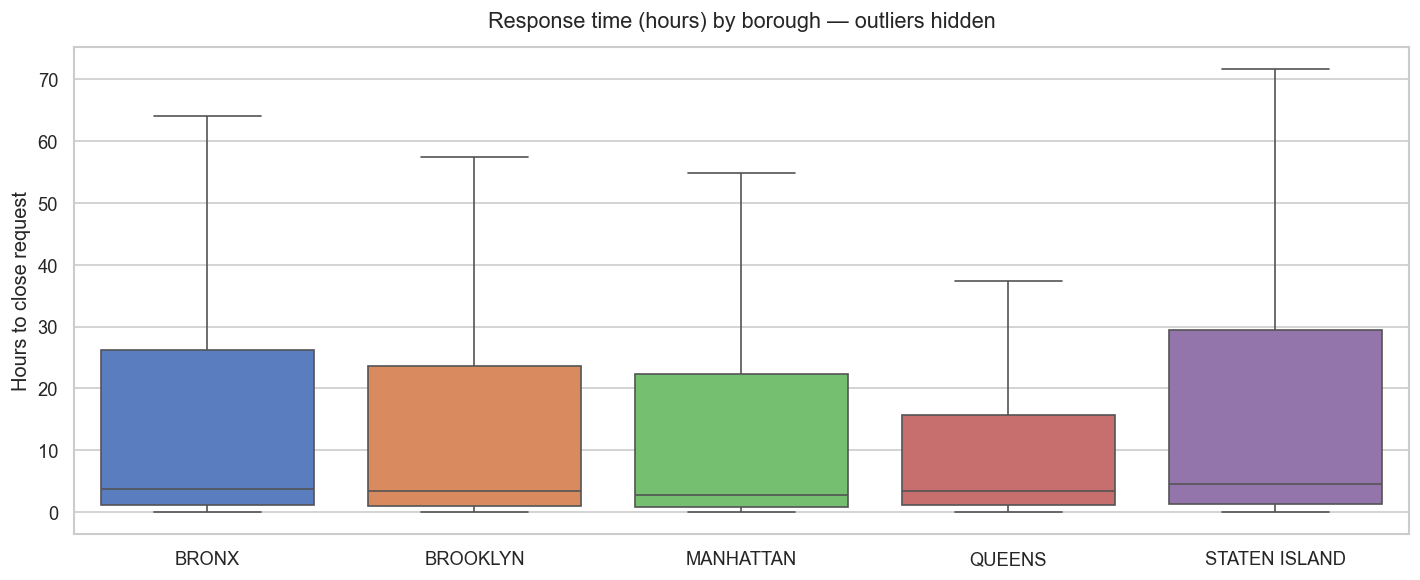

In [31]:
# --- Response time distribution by borough ---
if 'response_hours' in df.columns and 'borough' in df.columns:
    valid = df[df['response_hours'].notna() & (df['borough'] != 'UNKNOWN')]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=valid,
        x='borough',
        y='response_hours',
        order=sorted(valid['borough'].unique()),
        palette='muted',
        showfliers=False,   # hide extreme outliers for readability
        ax=ax
    )
    ax.set_title('Response time (hours) by borough — outliers hidden', fontsize=13, pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('Hours to close request')
    plt.tight_layout()
    plt.savefig('../data/fig_response_by_borough.png', bbox_inches='tight')
    plt.show()

---
## Stage 7 — Cleaning summary report

**Goal:** Produce a clear before/after comparison that documents exactly what this pipeline did and why. This is the most portfolio-important section — it demonstrates that you approach data cleaning as a professional process, not just code.

This summary should be included verbatim (or in slightly edited form) in the project README.

In [32]:
# Collect final metrics
final_shape = df.shape
final_nulls = df.isnull().sum().sum()
final_dupes = df.duplicated().sum()

# Compute deltas
rows_removed    = initial_shape[0] - final_shape[0]
cols_removed    = initial_shape[1] - final_shape[1]
nulls_reduced   = initial_nulls - final_nulls
dupes_removed   = initial_dupes - final_dupes
new_features    = len([c for c in df.columns if c in [
    'response_hours', 'day_of_week', 'hour_of_day', 'month', 'is_weekend', 'season'
]])

print('=' * 58)
print('  NYC 311 DATA CLEANING PIPELINE — SUMMARY REPORT')
print('=' * 58)
print(f'{"Metric":<35} {"Before":>10} {"After":>10}')
print('-' * 58)
print(f'{"Rows":<35} {initial_shape[0]:>10,} {final_shape[0]:>10,}')
print(f'{"Columns":<35} {initial_shape[1]:>10,} {final_shape[1]:>10,}')
print(f'{"Total null cells":<35} {initial_nulls:>10,} {final_nulls:>10,}')
print(f'{"Exact duplicate rows":<35} {initial_dupes:>10,} {final_dupes:>10,}')
print('-' * 58)
print(f'{"Rows removed":<35} {rows_removed:>10,}')
print(f'{"Columns removed (>80% null)":<35} {cols_removed:>10,}')
print(f'{"Null cells reduced":<35} {nulls_reduced:>10,}')
print(f'{"Duplicates removed":<35} {dupes_removed:>10,}')
print(f'{"New engineered features":<35} {new_features:>10,}')
print('=' * 58)

  NYC 311 DATA CLEANING PIPELINE — SUMMARY REPORT
Metric                                  Before      After
----------------------------------------------------------
Rows                                   200,000    155,793
Columns                                     44         41
Total null cells                     2,412,228    259,318
Exact duplicate rows                         0          0
----------------------------------------------------------
Rows removed                            44,207
Columns removed (>80% null)                  3
Null cells reduced                   2,152,910
Duplicates removed                           0
New engineered features                      6


In [33]:
# Final column inventory — what we're left with and their dtypes
col_summary = pd.DataFrame({
    'dtype':    df.dtypes.astype(str),
    'null_pct': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique()
}).reset_index().rename(columns={'index': 'column'})

print('Final dataset — column inventory:')
print(col_summary.to_string(index=False))

Final dataset — column inventory:
                        column          dtype  null_pct  n_unique
                    unique_key         object      0.00    155793
                  created_date datetime64[ns]      0.00    136479
                   closed_date datetime64[ns]     19.70    104422
                        agency         object      0.00        14
                   agency_name         object      0.00        14
                complaint_type         object      0.00        30
                    descriptor         object      1.43       703
                  descriptor_2         object     65.05       626
                 location_type         object     12.97       112
                  incident_zip         object      0.34       232
              incident_address         object      0.51     84812
                   street_name         object      0.51      7211
                cross_street_1         object      0.00      8630
                cross_street_2         obj

In [34]:
# Export cleaned dataset
OUTPUT_PATH = '../data/311_cleaned.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f'Clean dataset exported to {OUTPUT_PATH}')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Clean dataset exported to ../data/311_cleaned.csv
Final shape: 155,793 rows × 41 columns


---
## Cleaning decisions log

This section documents every substantive decision made in this pipeline. Good data cleaning is auditable — someone reading this notebook should be able to reproduce every choice.

| Decision | Rationale |
|----------|-----------|
| Loaded all columns as `str` initially | Prevents silent incorrect type inference on messy civic data |
| Dropped columns with ≥80% null values | Columns this sparse cannot be reliably imputed and add noise |
| Dropped rows with null `Unique Key` or `Created Date` | These are non-negotiable identifiers; a row without them is unusable |
| Filled optional location fields with `'UNKNOWN'` | Null = 'not provided by caller', not a data error; preserving the row is better than dropping |
| Preserved null `Closed Date` as `NaT` | Null = request still open; this is semantically correct, not a data error |
| Used `errors='coerce'` for date parsing | Safely handles format inconsistencies across years of data entry |
| Nullified coordinates outside NYC bounding box | Likely data entry errors; better to mark unknown than use wrong location |
| Nullified `Closed Date` < `Created Date` | Logically impossible; indicates a data entry error |
| Uppercased all text fields | Eliminates case-sensitivity false-distincts in groupby operations |
| Remapped borough variants to canonical names | 5 boroughs should produce 5 values, not dozens of variants |
| Bucketed rare complaint types as `'OTHER'` | Preserves top-30 signal without a long tail of noise |
| Capped response_hours at 8,760 (1 year) | Implausibly long times are data errors, not real resolution times |

---
*Project 3 of 4 · Riley Allen's Data Analytics Portfolio*  
*See also: [Project 1 — SQL](https://github.com/ryry2412/retail-ecommerce-sql) · [Project 2 — EDA & A/B Test](https://github.com/ryry2412/bank-marketing-eda-ab-test)*